<a href="https://www.kaggle.com/code/yanakutyshenko/notebook32c1bbb4fa?scriptVersionId=355832826" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
import os

data_dir = "/kaggle/input/datasets/yapwh1208/cats-breed-dataset/cat_v1"

print("Классы:")

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        print(class_name, "-", len(os.listdir(class_path)), "изображений")

Классы:
domestic_shorthair - 170 изображений
ragdoll - 207 изображений
siamese - 208 изображений
bengal - 177 изображений
maine_coon - 191 изображений


In [4]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [5]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=data_dir,
    transform=train_transform
)

print("Классы:", dataset.classes)
print("Количество изображений:", len(dataset))

Классы: ['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']
Количество изображений: 952


In [6]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Train: 761
Test: 191


In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 24
Test batches: 6


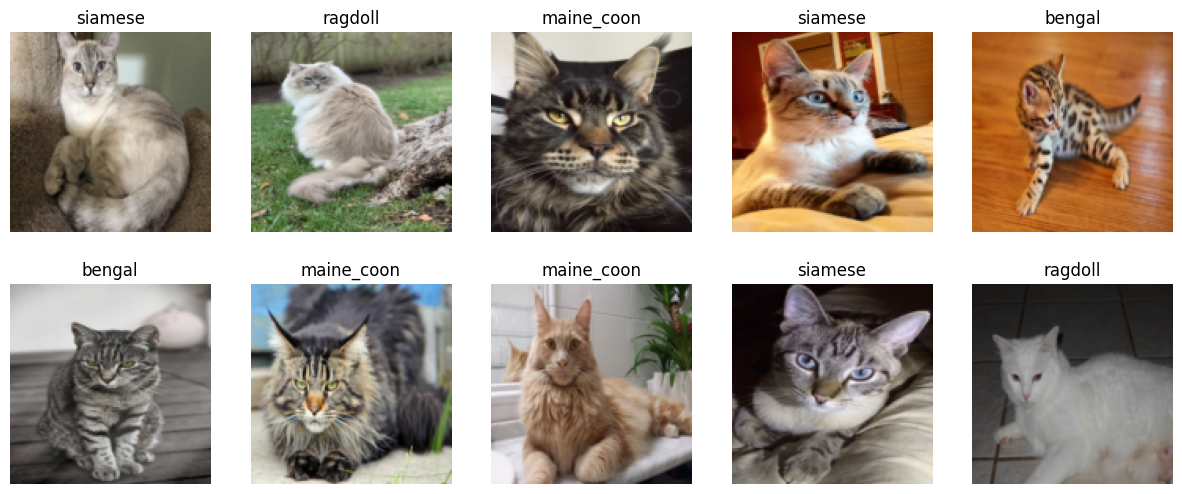

In [8]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(dataset.classes[labels[i]])
    ax.axis("off")

plt.show()

In [9]:
print("Размер batch изображений:", images.shape)
print("Размер batch labels:", labels.shape)
print("Классы:", dataset.classes)

Размер batch изображений: torch.Size([32, 3, 128, 128])
Размер batch labels: torch.Size([32])
Классы: ['bengal', 'domestic_shorthair', 'maine_coon', 'ragdoll', 'siamese']
